In [12]:
import pandas as pd
from pyhdf.SD import SD, SDC
import matplotlib.pyplot as plt
import pandas as pd
from itertools import islice
import io
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import re
from scipy.io import loadmat
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [122]:
import pandas as pd
from pyhdf.SD import SD, SDC

# --- REPLACE THIS STRING with the path to your NIST HDF file ---
file_path = r"C:\WINDLAB_SUMMER\ADW100o100D016a1950\ADW100o100D016a1950.HDF" 

print(f"--- Opening: {file_path} ---")

try:
    hdf_file = SD(file_path, SDC.READ)
    datasets = hdf_file.datasets()

    print(f"Success! Found {len(datasets)} datasets. Here is the structure:\n")
    for name, info in datasets.items():
        print(f" -> '{name}' | Shape (Dimensions): {info[1]}")
        
    hdf_file.end()
except Exception as e:
    print(f"Failed to read file. Error: {e}")

--- Opening: C:\WINDLAB_SUMMER\ADW100o100D016a1950\ADW100o100D016a1950.HDF ---
Success! Found 44 datasets. Here is the structure:

 -> 'File_Name' | Shape (Dimensions): (23, 1)
 -> 'Title' | Shape (Dimensions): (70, 1)
 -> 'BLWTL_Software_Version' | Shape (Dimensions): (1, 1)
 -> 'READ_ME' | Shape (Dimensions): (6385, 1)
 -> 'Wind_Angle' | Shape (Dimensions): (1, 1)
 -> 'Reference_Wind_Speed' | Shape (Dimensions): (1, 1)
 -> 'Exposure_Name' | Shape (Dimensions): (12, 1)
 -> 'Wind_Speed_Profile' | Shape (Dimensions): (5, 42)
 -> 'Roof_Slope_in_12' | Shape (Dimensions): (1, 1)
 -> 'Building_Height_Ft' | Shape (Dimensions): (1, 1)
 -> 'Building_Length_Ft' | Shape (Dimensions): (1, 1)
 -> 'Building_Width_Ft' | Shape (Dimensions): (1, 1)
 -> 'Building_Scale' | Shape (Dimensions): (1, 1)
 -> 'Building_Leakage' | Shape (Dimensions): (11, 1)
 -> 'Roof_Height_Velocity_Ratio' | Shape (Dimensions): (1, 1)
 -> 'Roof_Height_Velocity' | Shape (Dimensions): (1, 1)
 -> 'Building_Corners_3D' | Shape (D

In [14]:
def extract_to_dataframes(file_path, dataset_names):
    """
    Opens an HDF4 file, extracts specific datasets by name, 
    and returns a dictionary of Pandas DataFrames.
    """
    # Dictionary to store our final DataFrames
    extracted_dfs = {}
    
    try:
        # Open the file
        hdf_file = SD(file_path, SDC.READ)
        
        for name in dataset_names:
            try:
                # 1. Select the specific dataset
                dataset = hdf_file.select(name)
                
                # 2. Extract the raw Numpy array
                raw_data = dataset.get()
                
                # 3. Convert to Pandas DataFrame
                df = pd.DataFrame(raw_data)
                
                # 4. Store in our dictionary
                extracted_dfs[name] = df
                print(f"✅ Extracted '{name}' -> DataFrame Shape: {df.shape}")
                
                # Close the specific dataset connection
                dataset.endaccess()
                
            except Exception as e:
                print(f"❌ Could not extract '{name}'. Error: {e}")
                
        # Close the master file connection
        hdf_file.end()
        return extracted_dfs
        
    except Exception as e:
        print(f"Critical Error opening file: {e}")
        return None

target_datasets = ["Time_Series"] 

my_dataframes = extract_to_dataframes(file_path, target_datasets)

# You extract it like this:
df_cp = my_dataframes["Time_Series"]


print(df_cp)

✅ Extracted 'Time_Series' -> DataFrame Shape: (688, 49792)
     0      1      2      3      4      5      6      7      8      9      \
0      292    292    292    292    280    280    280    305    280    292   
1      250    262    262    286    250    262    262    262    274    262   
2      178    188    189    189    166    187    189    189    189    178   
3      -60    -62    -83    -76    -63    -51    -82    -86    -76    -95   
4      -65    -77    -70    -68    -68    -58    -75    -80    -80    -90   
..     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
683    307    311    303    300    295    300    295    303    300    292   
684    273    282    288    297    273    282    279    276    291    282   
685    287    281    300    287    276    281    297    279    287    276   
686    280    282    293    290    269    277    259    295    303    284   
687    277    277    276    267    287    277    277    287    277    287   

     ...  49782 

In [15]:
hdf_file = SD(file_path, SDC.READ)
all_dataset_names = list(hdf_file.datasets().keys()) # This gets a list of ALL names
hdf_file.end()

# 2. Feed that massive list into your extraction function
all_my_dataframes = extract_to_dataframes(file_path, all_dataset_names)

print(f"Successfully extracted {len(all_my_dataframes)} datasets into DataFrames!")

✅ Extracted 'File_Name' -> DataFrame Shape: (23, 1)
✅ Extracted 'Title' -> DataFrame Shape: (70, 1)
✅ Extracted 'BLWTL_Software_Version' -> DataFrame Shape: (1, 1)
✅ Extracted 'READ_ME' -> DataFrame Shape: (6385, 1)
✅ Extracted 'Wind_Angle' -> DataFrame Shape: (1, 1)
✅ Extracted 'Reference_Wind_Speed' -> DataFrame Shape: (1, 1)
✅ Extracted 'Exposure_Name' -> DataFrame Shape: (12, 1)
✅ Extracted 'Wind_Speed_Profile' -> DataFrame Shape: (5, 42)
✅ Extracted 'Roof_Slope_in_12' -> DataFrame Shape: (1, 1)
✅ Extracted 'Building_Height_Ft' -> DataFrame Shape: (1, 1)
✅ Extracted 'Building_Length_Ft' -> DataFrame Shape: (1, 1)
✅ Extracted 'Building_Width_Ft' -> DataFrame Shape: (1, 1)
✅ Extracted 'Building_Scale' -> DataFrame Shape: (1, 1)
✅ Extracted 'Building_Leakage' -> DataFrame Shape: (11, 1)
✅ Extracted 'Roof_Height_Velocity_Ratio' -> DataFrame Shape: (1, 1)
✅ Extracted 'Roof_Height_Velocity' -> DataFrame Shape: (1, 1)
✅ Extracted 'Building_Corners_3D' -> DataFrame Shape: (3, 10)
✅ Extract

In [16]:
print(all_my_dataframes['Wind_Speed_Profile'])

       0       1       2       3       4       5       6       7       8   \
0   1.270   1.270   3.050   3.660   4.880   6.100   7.320   8.530   9.750   
1   0.453   0.451   0.553   0.557   0.590   0.607   0.631   0.651   0.660   
2  24.313  23.589  20.436  19.256  18.999  18.127  17.973  16.967  16.842   
3   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   
4   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   

       9   ...       32       33       34       35       36       37       38  \
0  10.970  ...  107.290  110.950  114.600  118.110  121.920  132.080  144.780   
1   0.671  ...    0.923    0.946    0.927    0.943    0.964    0.965    0.985   
2  16.682  ...   12.623   11.843   12.146   11.591   11.349   10.618    9.735   
3   0.000  ...    0.000    0.000    0.000    0.000    0.000    0.000    0.000   
4   0.000  ...    0.000    0.000    0.000    0.000    0.000    0.000    0.000   

        39       40       41  
0  157.480  172.720

In [17]:
# 1. Extract BOTH datasets from the HDF file
target_datasets = ["Time_Series", "Ts_Multiplier"] 
my_dataframes = extract_to_dataframes(file_path, target_datasets)

# 2. Separate them into their own variables
df_raw_time_series = my_dataframes["Time_Series"]

# The multiplier is likely a 1x1 array, so we extract the exact number
multiplier_value = my_dataframes["Ts_Multiplier"].iloc[0, 0] 

# 3. Decode the data (Multiply the entire integer grid by the decimal factor)
df_real_time_series = df_raw_time_series * multiplier_value

# Verify the output (It should now match your MATLAB screenshot exactly)
print(df_real_time_series.head())

✅ Extracted 'Time_Series' -> DataFrame Shape: (688, 49792)
✅ Extracted 'Ts_Multiplier' -> DataFrame Shape: (1, 1)
   0      1      2      3      4      5      6      7      8      9      ...  \
0  0.292  0.292  0.292  0.292  0.280  0.280  0.280  0.305  0.280  0.292  ...   
1  0.250  0.262  0.262  0.286  0.250  0.262  0.262  0.262  0.274  0.262  ...   
2  0.178  0.188  0.189  0.189  0.166  0.187  0.189  0.189  0.189  0.178  ...   
3 -0.060 -0.062 -0.083 -0.076 -0.063 -0.051 -0.082 -0.086 -0.076 -0.095  ...   
4 -0.065 -0.077 -0.070 -0.068 -0.068 -0.058 -0.075 -0.080 -0.080 -0.090  ...   

   49782  49783  49784  49785  49786  49787  49788  49789  49790  49791  
0  0.268  0.268  0.280  0.268  0.280  0.256  0.280  0.280  0.268  0.268  
1  0.238  0.250  0.238  0.262  0.250  0.238  0.262  0.250  0.250  0.250  
2  0.188  0.189  0.189  0.178  0.188  0.178  0.188  0.189  0.189  0.189  
3 -0.015 -0.024 -0.036 -0.027 -0.025 -0.047 -0.050 -0.060 -0.062 -0.062  
4 -0.009 -0.016 -0.019 -0.039 -0.03

In [30]:
# 1. Extract the datasets required for the math
target_datasets = [
    "Time_Series", 
    "Ts_Multiplier", 
    "Roof_Height_Velocity_Ratio"
] 
my_dataframes = extract_to_dataframes(file_path, target_datasets)

# 2. Isolate the variables
df_raw_time_series = my_dataframes["Time_Series"]
multiplier_value = my_dataframes["Ts_Multiplier"].iloc[0, 0] 
uh_ratio = my_dataframes["Roof_Height_Velocity_Ratio"].iloc[0, 0]

# 3. Apply the aerodynamic standardization (Replicating Line 35 in MATLAB)
# In Python, ** is the exponent operator
df_real_time_series = (df_raw_time_series * multiplier_value * (1 / uh_ratio)**2).T

# 4. Check the results
print(df_real_time_series)

✅ Extracted 'Time_Series' -> DataFrame Shape: (688, 49792)
✅ Extracted 'Ts_Multiplier' -> DataFrame Shape: (1, 1)
✅ Extracted 'Roof_Height_Velocity_Ratio' -> DataFrame Shape: (1, 1)
            0         1         2         3         4         5         6    \
0      0.865029  0.740607  0.527312 -0.177746 -0.192558 -0.231069 -0.204407   
1      0.865029  0.776156  0.556936 -0.183671 -0.228107 -0.222182 -0.165896   
2      0.865029  0.776156  0.559899 -0.245881 -0.207370 -0.189595 -0.168858   
3      0.865029  0.847254  0.559899 -0.225144 -0.201445 -0.231069 -0.231069   
4      0.829480  0.740607  0.491763 -0.186633 -0.201445 -0.222182 -0.254769   
...         ...       ...       ...       ...       ...       ...       ...   
49787  0.758381  0.705058  0.527312 -0.139234 -0.151084 -0.162934 -0.148121   
49788  0.829480  0.776156  0.556936 -0.148121 -0.192558 -0.127384 -0.157009   
49789  0.829480  0.740607  0.559899 -0.177746 -0.142197 -0.162934 -0.145159   
49790  0.793931  0.740607  0

In [23]:
def view_history_at_tap(pressure_time_series, tap_no, time_a, time_b):
    tap_idx = int(tap_no)
    start_idx = int(time_a)
    end_idx = int(time_b)


    pressure_tap_no = pressure_time_series[tap_idx]

    sliced_pressure = pressure_tap_no.iloc[start_idx: end_idx]

    plt.plot(
        sliced_pressure.index, 
        sliced_pressure.values, 
        color='#1f77b4', 
        linewidth=0.5, 
        label=f'Tap Channel {tap_no}'
    )

    plt.title(f'Pressure Coefficient Time Series - Tap {tap_no}', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Timestep (Frames / Samples)', fontsize=10)
    plt.ylabel('Pressure Value ($C_p$)', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()

    plt.show()

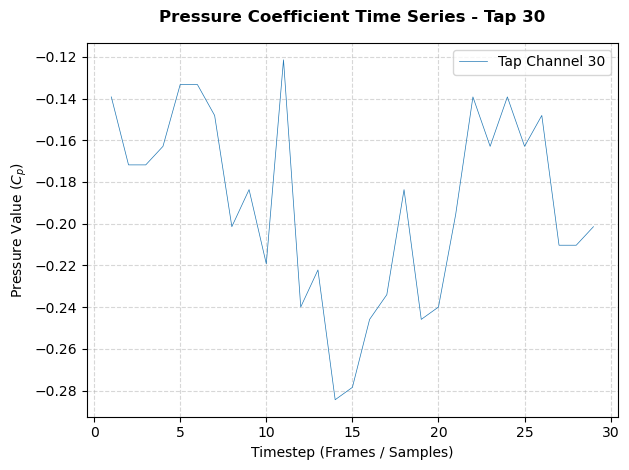

In [32]:
view_history_at_tap(df_real_time_series, 30, 1, 30)

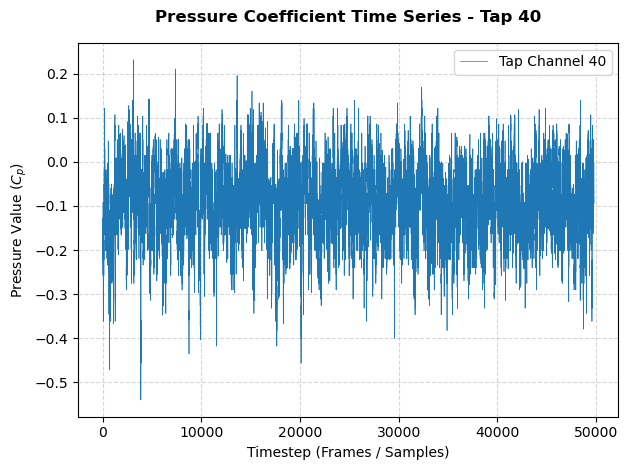

In [96]:
def view_full_series_tap(pressure_time_series, tap_no):
    tap_idx = int(tap_no)

    pressure_at_tap = pressure_time_series[tap_idx]


    plt.plot(
        pressure_at_tap.index, 
        pressure_at_tap.values, 
        color='#1f77b4', 
        linewidth=0.5, 
        label=f'Tap Channel {tap_no}'
    )

    
    plt.title(f'Pressure Coefficient Time Series - Tap {tap_no}', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Timestep (Frames / Samples)', fontsize=10)
    plt.ylabel('Pressure Value ($C_p$)', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()

    plt.show()


view_full_series_tap(df_real_time_series, 40)

In [68]:
print(all_my_dataframes['Tap_Coordinates_3D'].T)
#print(all_my_dataframes['Wire_Frame_Lines_3D'].T)
#print(all_my_dataframes['Building_Corners_3D'].T)


          0    1      2      3      4
0     104.0  3.0  34.36  125.0   4.00
1     105.0  3.0  34.36  125.0   9.00
2     106.0  3.0  34.36  125.0  14.00
3     107.0  3.0  34.36  125.0  16.64
4     108.0  3.0  28.71  125.0  14.00
..      ...  ...    ...    ...    ...
499  4015.0  3.0  68.21  125.0   4.00
500  4016.0  3.0  73.86  125.0   4.00
501  4101.0  3.0  79.50  125.0   3.17
502  4210.0  0.0  41.00   62.5   0.00
503  4211.0  0.0  39.00   62.5   0.00

[504 rows x 5 columns]


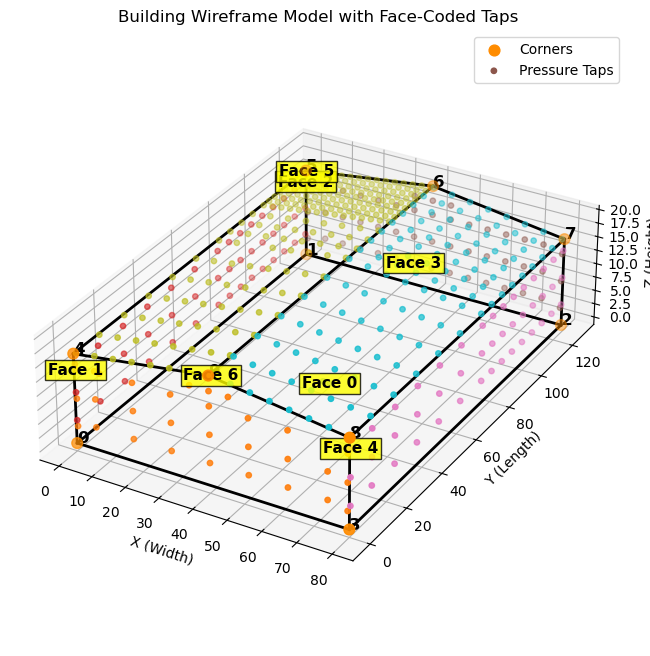

In [71]:
def get_wind_frame_plot_3D(tap_df, frame_df, corners_df):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(corners_df[0], corners_df[1], corners_df[2], 
        color='darkorange', s=60, label='Corners')
    
    for _, line in frame_df.iterrows():
        start_id = int(line[0]) - 1
        end_id = int(line[1]) - 1


        start_node = corners_df.iloc[start_id]
        end_node = corners_df.iloc[end_id]

    
        xs = [start_node[0], end_node[0]]
        ys = [start_node[1], end_node[1]]
        zs = [start_node[2], end_node[2]]

        ax.plot(xs, ys, zs, color='black', linewidth=2)

    for i, row in corners_df.iterrows():
        ax.text(row[0], row[1], row[2], str(i), fontsize=12, fontweight='bold')

    scatter = ax.scatter(tap_df[2], tap_df[3], tap_df[4], 
                    c=tap_df[1], 
                    cmap='tab10', 
                    s=15, 
                    label='Pressure Taps')
    

    seen_faces = set()

    # 3. Iterate through every tap
    for index, row in tap_df.iterrows():
        # Extract the data from the columns
        tap_id = row[0]
        face_num = row[1]
        x = row[2]
        y = row[3]
        z = row[4]
        
        # 4. Check if we have NEVER seen this face before
        if face_num not in seen_faces:
            # We found a completely new face! Plot the text.
            label_text = f"Face {int(face_num)}" 
            
            ax.text(x, y, z, label_text, 
                    color='black', 
                    fontsize=11, 
                    fontweight='bold',
                    ha='center', 
                    va='center',
                    bbox=dict(facecolor='yellow', alpha=0.8, edgecolor='black', pad=2))
            
            # 5. Add this face to our "seen" list so it NEVER prints again
            seen_faces.add(face_num)


    ax.set_xlabel('X (Width)')
    ax.set_ylabel('Y (Length)')
    ax.set_zlabel('Z (Height)')
    ax.set_title('Building Wireframe Model with Face-Coded Taps')

    ax.set_box_aspect([100, 145, 40]) 
    ax.legend()

    plt.show()

get_wind_frame_plot_3D(all_my_dataframes['Tap_Coordinates_3D'].T, all_my_dataframes['Wire_Frame_Lines_3D'].T, all_my_dataframes['Building_Corners_3D'].T)


In [92]:
flat_tap_coords = all_my_dataframes['Flat_Tap_Coordinates'].T
print(flat_tap_coords)

flat_corners_df = all_my_dataframes['Building_Corners_Flat'].T
#print(flat_corners_df)

flat_frames_df = all_my_dataframes['Flat_Wire_Frame_Lines'].T
#print(flat_frames_df)

          0    1      2       3
0     104.0  3.0  34.36  148.33
1     105.0  3.0  34.36  143.33
2     106.0  3.0  34.36  138.33
3     107.0  3.0  34.36  135.69
4     108.0  3.0  28.71  138.33
..      ...  ...    ...     ...
497  4013.0  3.0  56.93  148.33
498  4014.0  3.0  62.57  148.33
499  4015.0  3.0  68.21  148.33
500  4016.0  3.0  73.86  148.33
501  4101.0  3.0  79.50  149.17

[502 rows x 4 columns]


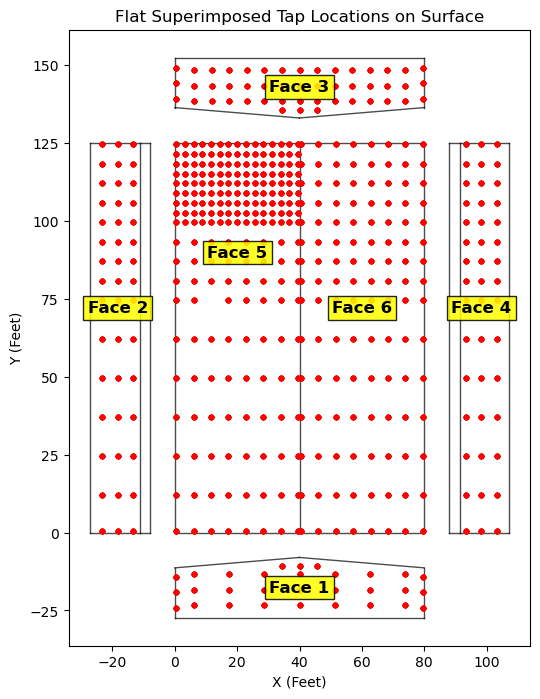

In [94]:
plt.figure(figsize=(10, 8))

# Draw the lines connecting corners based on your pairs dataframe
for _, row in flat_frames_df.iterrows():
    idx1 = int(row.iloc[0]) - 1 
    idx2 = int(row.iloc[1]) - 1

    
    # Pull the corresponding X and Y from your corners dataframe
    x_vals = [flat_corners_df.iloc[idx1, 0], flat_corners_df.iloc[idx2, 0]]
    y_vals = [flat_corners_df.iloc[idx1, 1], flat_corners_df.iloc[idx2, 1]]
    
    plt.plot(x_vals, y_vals, color='black', linewidth=1, alpha=0.7)


    plt.scatter(
    flat_tap_coords[2], 
    flat_tap_coords[3], 
    color='red',          # Make them stand out
    s=8,                 # Size of the dots
    marker='o',           # Shape (circle)
    label='Pressure Taps',
    zorder=3              # Ensures points stay ON TOP of the lines
    )


unique_faces = flat_tap_coords.iloc[:, 1].unique()

# 2. Loop through each face one by one
for face in unique_faces:
    # 3. Filter the dataframe to ONLY show taps on the current face
    face_data = flat_tap_coords[flat_tap_coords.iloc[:, 1] == face]

    # 4. Calculate the exact center point (Average X and Y)
    center_x = face_data.iloc[:, 2].mean()
    center_y = face_data.iloc[:, 3].mean()

    # 5. Place the label perfectly in the middle
    plt.text(center_x, center_y, f"Face {int(face)}", 
            color='black', 
            fontsize=12, 
            fontweight='bold',
            ha='center', 
            va='center',
            bbox=dict(facecolor='yellow', alpha=0.85, edgecolor='black', pad=3))
    


plt.title("Flat Superimposed Tap Locations on Surface")
plt.xlabel("X (Feet)")
plt.ylabel("Y (Feet)")
plt.gca().set_aspect('equal')
plt.show()

In [114]:
mean_cp_series = df_real_time_series.mean(axis = 0)

mean_cp_df = mean_cp_series.reset_index()
mean_cp_df.columns = ['Tap no.', 'mean_cp']

print(mean_cp_df)



     Tap no.   mean_cp
0          0  0.819718
1          1  0.768035
2          2  0.530886
3          3 -0.205054
4          4 -0.199513
..       ...       ...
683      683  0.865701
684      684  0.833147
685      685  0.824482
686      686  0.829631
687      687  0.810120

[688 rows x 2 columns]


In [115]:
all_means = mean_cp_df['mean_cp'].values
num_taps = len(flat_tap_coords)
matched_means = all_means[:num_taps]

# 4. Paste it directly into the coordinate DataFrame
flat_tap_coords['mean_cp'] = matched_means

print(f"Successfully mapped {len(matched_means)} mean Cp values to the coordinates.")

#print(matched_means)



Successfully mapped 502 mean Cp values to the coordinates.


In [116]:
face_dfs = {}

# 2. Find all the unique face numbers in your dataset (e.g., [1.0, 2.0, 3.0...])
# Using dropna() ensures we don't accidentally create a dataset for "NaN" faces
unique_faces = flat_tap_coords[1].dropna().unique()

# 3. Loop through and slice the master table
for face_num in unique_faces:
    # Filter the master table for this specific face and create a clean copy
    face_data = flat_tap_coords[flat_tap_coords[1] == face_num].copy()
    
    # Store it in the dictionary using the face number as the key
    face_dfs[face_num] = face_data

# 4. Print a summary to verify it worked perfectly
print("--- Data Separated by Face ---")
for face_num, df in face_dfs.items():
    print(f"Face {face_num}: {len(df)} taps ready for plotting.")

print(face_dfs[3])

--- Data Separated by Face ---
Face 3.0: 48 taps ready for plotting.
Face 2.0: 45 taps ready for plotting.
Face 5.0: 214 taps ready for plotting.
Face 1.0: 30 taps ready for plotting.
Face 6.0: 120 taps ready for plotting.
Face 4.0: 45 taps ready for plotting.
          0    1      2       3   mean_cp
0     104.0  3.0  34.36  148.33  0.819718
1     105.0  3.0  34.36  143.33  0.768035
2     106.0  3.0  34.36  138.33  0.530886
3     107.0  3.0  34.36  135.69 -0.205054
4     108.0  3.0  28.71  138.33 -0.199513
5     109.0  3.0  28.71  143.33 -0.228915
6     110.0  3.0  28.71  148.33 -0.194186
7     201.0  3.0  23.07  148.33 -0.147223
8     202.0  3.0  23.07  143.33 -0.149417
9     203.0  3.0  23.07  138.33 -0.183283
10    204.0  3.0  17.43  138.33  0.775465
11    205.0  3.0  17.43  143.33  0.773276
12    206.0  3.0  17.43  148.33  0.772661
13    213.0  3.0  11.79  148.33  0.791832
14    214.0  3.0  11.79  143.33  0.796005
15    215.0  3.0  11.79  138.33  0.785850
16    216.0  3.0   6.14  

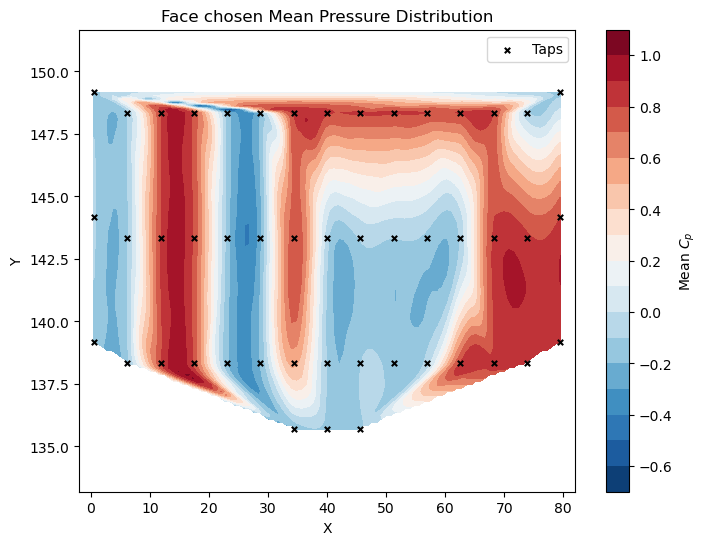

In [121]:
face_df = face_dfs[3]

x = face_df[2].values
y = face_df[3].values
z = face_df['mean_cp'].values

# 2. Define the grid resolution
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),
    np.linspace(y.min(), y.max(), 100)
)

# 3. Interpolate the mean_cp values onto the grid
grid_z = griddata((x, y), z, (grid_x, grid_y), method='cubic')

# 4. Generate the contour plot
plt.figure(figsize=(8, 6))
contour = plt.contourf(grid_x, grid_y, grid_z, levels=20, cmap='RdBu_r')
plt.colorbar(contour, label="Mean $C_p$")

# Optional: Overlay the tap locations to verify grid coverage
plt.scatter(x, y, c='black', s=15, marker='x', label='Taps')

plt.title("Face chosen Mean Pressure Distribution")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()

# Grab your current minimums and maximums
current_x_min, current_x_max = plt.xlim()
current_y_min, current_y_max = plt.ylim()

# Add a 5-unit "buffer" to all sides to zoom out
buffer = 2.5 
plt.xlim(current_x_min - buffer, current_x_max + buffer)
plt.ylim(current_y_min - buffer, current_y_max + buffer)
plt.show()